# Просмотр теплового видео из `.mat`

В этом файле `data` имеет форму `(высота, ширина, кадры)`. Каждый кадр содержит **одно значение температуры на пиксель**, поэтому отдельного RGB-изображения в файле нет. Ниже исходный кадр показывается в оттенках серого, а те же данные — как цветная термограмма со шкалой в °C.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display
from scipy.io import loadmat

In [2]:
MAT_PATH = Path("data/deffect/Sample 4 Static.mat")
mat = loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

thermal = np.asarray(mat["data"], dtype=np.float32)
if thermal.ndim != 3:
    raise ValueError(f"Ожидался массив (H, W, N), получено {thermal.shape}")

height, width, frame_count = thermal.shape
fps_from_file = float(mat.get("FPS", 0.0))
PLAYBACK_FPS = fps_from_file if np.isfinite(fps_from_file) and fps_from_file > 0 else 25.0

print(f"Размер кадра: {width}×{height}")
print(f"Количество кадров: {frame_count}")
print(f"FPS в файле: {fps_from_file}; для воспроизведения: {PLAYBACK_FPS}")
print(f"Диапазон данных: {np.nanmin(thermal):.2f}…{np.nanmax(thermal):.2f} °C")

Размер кадра: 320×240
Количество кадров: 2000
FPS в файле: 0.0; для воспроизведения: 25.0
Диапазон данных: 19.30…62.69 °C


## Единая температурная шкала

Одна шкала для всех кадров не дает цветам «прыгать» во время видео. Перцентили отбрасывают единичные выбросы. При необходимости задайте `TEMP_MIN` и `TEMP_MAX` вручную.

In [3]:
# Для оценки шкалы достаточно равномерно взять не более 100 кадров.
sample_step = max(1, frame_count // 100)
sample = thermal[:, :, ::sample_step]
TEMP_MIN, TEMP_MAX = np.nanpercentile(sample, [1.0, 99.5]).astype(float)
TEMP_MIN, TEMP_MAX = 0.0, 100.0

# Пример ручной шкалы: TEMP_MIN, TEMP_MAX = 20.0, 50.0
print(f"Шкала отображения: {TEMP_MIN:.2f}…{TEMP_MAX:.2f} °C")

Шкала отображения: 0.00…100.00 °C


NameError: name 'TEMP_MIN' is not defined

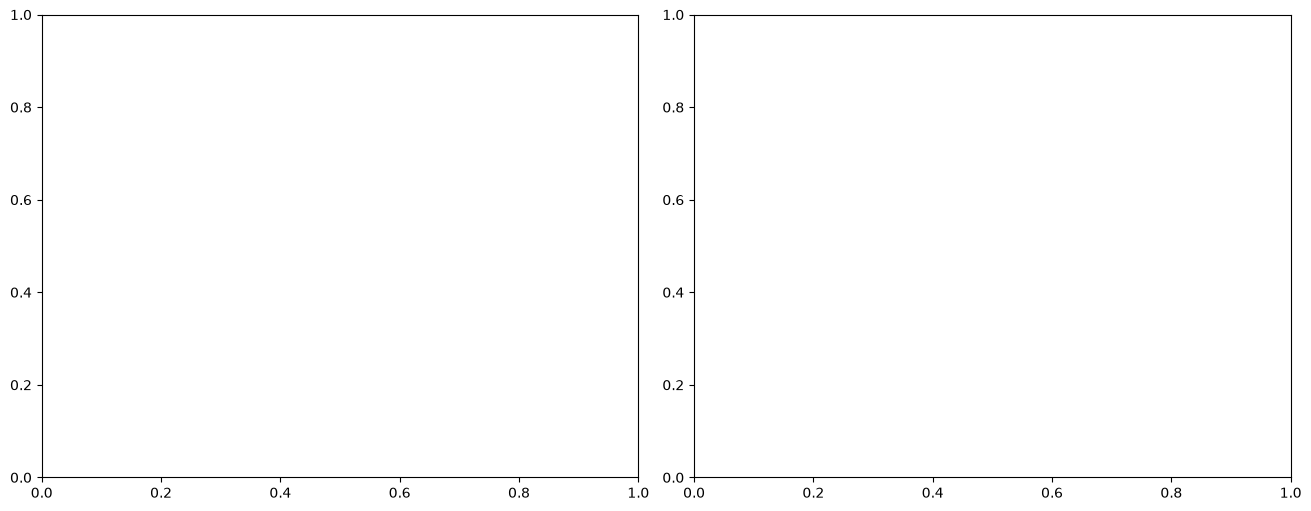

In [3]:
def show_frame(frame_index: int = 0) -> None:
    if not 0 <= frame_index < frame_count:
        raise IndexError(f"Номер кадра должен быть от 0 до {frame_count - 1}")

    frame = thermal[:, :, frame_index]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].imshow(frame, cmap="gray", vmin=TEMP_MIN, vmax=TEMP_MAX)
    axes[0].set_title("Исходные данные (оттенки серого)")

    image = axes[1].imshow(frame, cmap="inferno", vmin=TEMP_MIN, vmax=TEMP_MAX)
    axes[1].set_title("Цветная термограмма")
    colorbar = fig.colorbar(image, ax=axes[1], shrink=0.85)
    colorbar.set_label("Температура, °C")

    for axis in axes:
        axis.set_axis_off()

    fig.suptitle(
        f"Кадр {frame_index}/{frame_count - 1} — "
        f"min {np.nanmin(frame):.1f} °C, max {np.nanmax(frame):.1f} °C"
    )
    plt.show()


FRAME_INDEX = 100
show_frame(FRAME_INDEX)

## Сохранение и просмотр видео

Ячейка создает MP4: слева серый кадр, справа цветная термограмма. Поскольку `FPS` в исходном файле равен нулю, скорость задается переменной `PLAYBACK_FPS` выше.

In [4]:
#Сохранение видео
def render_video(
    input_path: str | Path,
    output_path: str | Path,
    fps: float = 25.0
) -> Path:
    #Загрузка данных из .mat
    
    input_path = Path(input_path)
    if not input_path.exists():
        raise RuntimeError("Input file can not be find")
    
    if input_path.is_dir():
        return ''
    
    mat_file = loadmat(input_path, squeeze_me=True, struct_as_record=False)
    
    thermal = np.asarray(mat_file["data"], dtype=np.float32)
    height, width, frame_count = thermal.shape
    # Не изменяем исходную шкалу температур при рендеринге.
    TEMP_MIN, TEMP_MAX = np.nanpercentile(thermal, [1.0, 99.5]).astype(float)
    
    fps_from_file = float(mat_file.get("FPS", 0.0))
    PLAYBACK_FPS = fps_from_file if np.isfinite(fps_from_file) and fps_from_file > 0 else 25.0
    
    
    
    output_path = Path(output_path)
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps, 
        (width, height),
    )
    if not writer.isOpened():
        raise RuntimeError("It is not allowed to open mp4v codec")
    
    inferno = plt.colormaps["inferno"]
    scale = TEMP_MAX - TEMP_MIN
    
    try:
        for frame_index in range(frame_count):
            frame = thermal[:, :, frame_index]
            normalized = np.nan_to_num(
                (frame - TEMP_MIN) / scale, nan=0.0, posinf=1.0, neginf=0.0
            )
            normalized = np.clip(normalized, 0.0, 1.0)
            
            gray = (normalized * 255).astype(np.uint8)
            gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
            heat_rgb = (inferno(normalized)[..., :3] * 255).astype(np.uint8)
            # combined_rgb = np.concatenate([gray_rgb, heat_rgb], axis=1)

            # OpenCV записывает BGR, а Matplotlib возвращает RGB.
            writer.write(cv2.cvtColor(heat_rgb, cv2.COLOR_RGB2BGR))
    finally:
        writer.release()

    return output_path

In [6]:
def export_comparison_video(
    output_path: str | Path = "thermal_comparison.mp4",
    fps: float | None = None,
) -> Path:
    output_path = Path(output_path)
    if fps is None:
        fps = PLAYBACK_FPS
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width * 2, height),
    )
    if not writer.isOpened():
        raise RuntimeError("Не удалось открыть кодек mp4v для записи видео")

    inferno = plt.colormaps["inferno"]
    scale = TEMP_MAX - TEMP_MIN

    try:
        for frame_index in range(frame_count):
            frame = thermal[:, :, frame_index]
            normalized = np.nan_to_num(
                (frame - TEMP_MIN) / scale, nan=0.0, posinf=1.0, neginf=0.0
            )
            normalized = np.clip(normalized, 0.0, 1.0)

            gray = (normalized * 255).astype(np.uint8)
            gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
            heat_rgb = (inferno(normalized)[..., :3] * 255).astype(np.uint8)
            combined_rgb = np.concatenate([gray_rgb, heat_rgb], axis=1)

            # OpenCV записывает BGR, а Matplotlib возвращает RGB.
            writer.write(cv2.cvtColor(combined_rgb, cv2.COLOR_RGB2BGR))
    finally:
        writer.release()

    return output_path


video_path = export_comparison_video()
display(Video(str(video_path), embed=False, width=960))

In [5]:
input_file = "data/deffect/Sample 21 Static.mat"
output_file = "output.mp4"
render_video(input_path=input_file, output_path=output_file)

PosixPath('output.mp4')

In [8]:
data_dir = "data/deffect/"
path_data_dir = Path(data_dir)
output_dir = "data/render"
path_output_dir = Path(output_dir)
if not path_output_dir.exists():
    path_output_dir.mkdir()

for path_to_file in path_data_dir.glob("*.mat"):
    name = path_to_file.name # Выдает название файла с расширением
    
    output_file_path = path_output_dir / name
    output_file_path = output_file_path.with_suffix(".mp4")
    render_video(input_path=path_to_file, output_path=output_file_path)

KeyboardInterrupt: 

In [6]:
def gradient(
    img: cv2.typing.MatLike,
    mode: str = "sobel",
) -> cv2.typing.MatLike:
    if mode == "sobel":
        sobelx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
        sobely = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)

        grad_mag = cv2.magnitude(sobelx, sobely)
        grad_mag = cv2.normalize(
            grad_mag, None, 0, 255, cv2.NORM_MINMAX
        ).astype(np.uint8)
        grad_bgr = cv2.cvtColor(grad_mag, cv2.COLOR_GRAY2BGR)
        return grad_bgr
    elif (mode == 'laplas'):
        return cv2.Laplacian(img, 1, ksize=3)
    else:
        return 

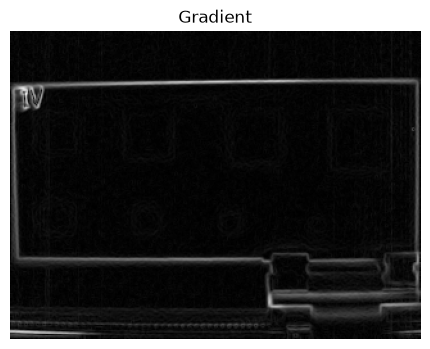

In [10]:
smpl = sample[:, :, 50].astype(np.float32)

sobelx = cv2.Sobel(smpl, cv2.CV_32F, 1, 0, ksize=3)
sobely = cv2.Sobel(smpl, cv2.CV_32F, 0, 1, ksize=3)

grad_mag = cv2.magnitude(sobelx, sobely)
grad_mag = cv2.normalize(
    grad_mag, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.imshow(grad_mag, cmap="gray")
plt.title("Gradient")
plt.axis("off")
plt.show()

In [7]:
def grad_video(
    input_path: str | Path,
    output_path: str | Path,
    fps: float | None = None,
    gamma: float = 0.5,
    mode: str = 'sobel',
):
    if gamma <= 0:
        raise ValueError("gamma должен быть больше нуля")

    input_path = Path(input_path)
    if fps is None:
        fps = PLAYBACK_FPS
    output_path = Path(output_path)

    mat = loadmat(input_path, squeeze_me=True, struct_as_record=False)

    thermal = np.asarray(mat["data"], dtype=np.float32)
    height, width, frame_count = thermal.shape
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height),
    )
    try:
        for frame in range(frame_count):
            smpl = thermal[:, :, frame]
            sobelx = cv2.Sobel(smpl, cv2.CV_32F, 1, 0, ksize=3)
            sobely = cv2.Sobel(smpl, cv2.CV_32F, 0, 1, ksize=3)

            grad_mag = cv2.magnitude(sobelx, sobely)
            grad_norm = cv2.normalize(
                grad_mag, None, 0.0, 1.0, cv2.NORM_MINMAX
            )
            grad_mag = (np.power(grad_norm, gamma) * 255).astype(np.uint8)
            grad_bgr = cv2.cvtColor(grad_mag, cv2.COLOR_GRAY2BGR)
            writer.write(grad_bgr)
    finally:
        writer.release()
    
    

In [12]:
input_path = "data/deffect/Sample 4 Static.mat"
output_path = "gradient.mp4"
grad_video(input_path, output_path, mode='laplas')

In [8]:
output_path = 'data/gradient'
input_dir = 'data'
output_path = Path(output_path)
input_path = Path(input_dir)

if not output_path.exists():
    output_path.mkdir()

for file in input_path.iterdir():
    if file.is_dir():
        continue
    
    output_file = output_path / file.name
    output_file = output_file.with_suffix(".mp4")
    grad_video(file, output_file)
    print(output_file)
    

In [14]:
# Посмотрим на то, как на изображение повлияет gamma изменение:
input_file = "data/deffect/Sample 3 Static.mat"
output_file = 'gamma_correction.mp4'
render_video(input_file, output_file)

PosixPath('gamma_correction.mp4')

In [9]:
def compare_gamma_correction(
    input_path: str | Path,
    output_path: str | Path,
    gamma: float = 3.0,
    fps: float = 25.0,
):
    if gamma <= 0:
        raise ValueError("gamma должен быть больше нуля")

    input_path = Path(input_path)
    output_path = Path(output_path)
    mat = loadmat(input_path, squeeze_me=True, struct_as_record=False)
    thermal = np.asarray(mat["data"], dtype=np.float32)
    height, width, frame_count = thermal.shape

    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width * 2, height),
    )
    if not writer.isOpened():
        raise RuntimeError("Не удалось открыть видео для записи")

    try:
        for frame_index in range(frame_count):
            frame = thermal[:, :, frame_index]
            normalized = cv2.normalize(
                frame, None, 0.0, 1.0, cv2.NORM_MINMAX
            )
            corrected = np.power(normalized, gamma)

            original_gray = (normalized * 255).astype(np.uint8)
            corrected_gray = (corrected * 255).astype(np.uint8)
            original_bgr = cv2.cvtColor(original_gray, cv2.COLOR_GRAY2BGR)
            corrected_bgr = cv2.cvtColor(corrected_gray, cv2.COLOR_GRAY2BGR)
            combined = np.concatenate((original_bgr, corrected_bgr), axis=1)
            writer.write(combined)
    finally:
        writer.release()


In [16]:
compare_gamma_correction(input_file, output_file, 5)

In [10]:
from water_processing import render_video_stream

input_path = "data/water/water1.mat"
render_video_stream(input_path, "water_render.mp4")


Обработано кадров: 100/3000
Обработано кадров: 200/3000
Обработано кадров: 300/3000
Обработано кадров: 400/3000
Обработано кадров: 500/3000
Обработано кадров: 600/3000
Обработано кадров: 700/3000
Обработано кадров: 800/3000
Обработано кадров: 900/3000
Обработано кадров: 1000/3000
Обработано кадров: 1100/3000
Обработано кадров: 1200/3000
Обработано кадров: 1300/3000
Обработано кадров: 1400/3000
Обработано кадров: 1500/3000
Обработано кадров: 1600/3000
Обработано кадров: 1700/3000
Обработано кадров: 1800/3000
Обработано кадров: 1900/3000
Обработано кадров: 2000/3000
Обработано кадров: 2100/3000
Обработано кадров: 2200/3000
Обработано кадров: 2300/3000
Обработано кадров: 2400/3000
Обработано кадров: 2500/3000
Обработано кадров: 2600/3000
Обработано кадров: 2700/3000
Обработано кадров: 2800/3000
Обработано кадров: 2900/3000
Обработано кадров: 3000/3000


PosixPath('water_render.mp4')

In [12]:
from water_processing import compare_gamma_correction_stream

compare_gamma_correction_stream(input_path, "water_gamma_correction.mp4")


PosixPath('water_gamma_correction.mp4')

In [11]:
from water_processing import grad_video_stream

grad_video_stream(input_path, "water_grad.mp4")


PosixPath('water_grad.mp4')

In [ ]:
img = cv2.imread("00033.jpg")
display(img.shape)

rect = cv2.rectangle(img, (150, 50), (490, 400), color=128)
cv2.imshow('', rect)
cv2.waitKey(0)
cv2.destroyAllWindows()

#x1 = 150, y1 = 50, x2 = 490, y2 = 400

(480, 640, 3)